## PMM Shell Model: Complete case

This notebook is an example of using affine effective PMMs in order to compute the ground state and several excited states of the nuclear shell model for the $^{20} \text{Ne}$ nucleus, only considering the valence shell.

In [1]:
import numpy as np
from scipy.sparse import csr_matrix
import math
import jax.numpy as jnp
from jax import grad, lax, jit
from matplotlib import pyplot as plt
import sys
import pynucshell as pns
import sympy as sp
from mpl_toolkits.mplot3d import Axes3D

We will use a collective Hamiltonian, where only the dominant terms are considered. Our aim is to reproduce the sd shell with a single effective PMM.

$$\mathcal{H}_{\text{coll}} =  \mathcal{H}_{\text{mono}}+g^{T=1}\mathcal{H}_{\text{pair}}^{(T=1)}+g^{T=0}\mathcal{H}_{\text{pair}}^{(T=0)}+\chi \mathcal{H}_{QQ}$$

The fitted values of each strength parameter for the $^{20} \text{Ne}$ are:

$$
\begin{gather*}
\text{Isovector pairing:} \quad g^{T=1}= 1.334\\
\text{Isoscalar pairing:} \quad g^{T=0}= 6.202\\
\text{Q-Q interaction:} \quad \chi= 0.634


\end{gather*}
$$

Start by defining the space of the sd shell while considering the closed shell as an inert core.


In [2]:
sd_shell = pns.Space([0,1,0],[2,0,2],[2.5,0.5,1.5]) # |nlj>
sd_shell.print_space()


  0d₃/₂          11    10     9     8                    23    22    21    20         
                ----- ----- ----- -----                 ----- ----- ----- -----       

  1s₁/₂                 7     6                                19    18               
                      ----- -----                             ----- -----             

  0d₅/₂     5     4     3     2     1     0        17    16    15    14    13    12   
          ----- ----- ----- ----- ----- -----     ----- ----- ----- ----- ----- ----- 

           -5    -3    -1     1     3     5        -5    -3    -1     1     3     5   



We now import the Hamiltonians from the data. The `pns.Operator.from_coupled_file` creates an operator, in this case our Hamiltonian, from a file which has the interactions in the coupled representation.

In [4]:
H_USDB = pns.Operator.from_coupled_file(sd_shell, 'hamil/usdb_b.int')
H_MONO = pns.Operator.from_coupled_file(sd_shell, 'hamil/sd_mono')
H_QQ = pns.Operator.from_coupled_file(sd_shell, 'hamil/sd_qq')
H_PJ1T0 = pns.Operator.from_coupled_file(sd_shell, 'hamil/sd_PJ1T0')
H_PJ0T1 = pns.Operator.from_coupled_file(sd_shell, 'hamil/sd_PJ0T1')
H_COL = pns.Operator.from_coupled_file(sd_shell, 'hamil/sd_col')

Once that the general, two-body Hamiltonian is imported, we specify the number of protons and neutrons in this space. As we are considering $^{20} \text{Ne}$ nucleus, we add 2 protons and 2 neutrons to the inert core:

In [5]:
N_protons = 2
N_neutrons = 2
J_total = 0

For the matrices, we use the `pns.Hamiltonian` class, which provides some utilities for quantum calculations. One of them, is the `to_dense` method, which returns a standard `numpy` array.

In [6]:
ne20_MONO = pns.Hamiltonian(N_protons, N_neutrons, J_total, sd_shell, H_MONO).to_dense()
ne20_QQ = pns.Hamiltonian(N_protons, N_neutrons, J_total, sd_shell, H_QQ).to_dense()
ne20_PJ1T0 = pns.Hamiltonian(N_protons, N_neutrons, J_total, sd_shell, H_PJ1T0).to_dense()
ne20_PJ0T1 = pns.Hamiltonian(N_protons, N_neutrons, J_total, sd_shell, H_PJ0T1).to_dense()
ne20_col = pns.Hamiltonian(N_protons, N_neutrons, J_total, sd_shell, H_COL).to_dense()

For this complete demonstration, we will study over all three strength parameters. Let's consider the next ranges to study each parameter:
$$
\begin{gather*}
g^{T=1} \in [0,2] \\
g^{T=0} \in [5,7] \\
\chi \in [0,1]
\end{gather*}

$$


As before, we will explore around the fitted strengths.

In [ ]:
k=3 #number of eigenvalues to train on

# Test set generation

ntest=21 #number of test points for each parameter

givec_test=np.linspace(0,2,ntest) #Isovector pairing strength
giesc_test=np.linspace(5,7,ntest) #Isoscalar pairing strength
chillqq_test=np.linspace(0,1,ntest) #Quadrupole-quadrupole interaction strength


# Compute the k-lowest energy state for testing
E_test = []
g_test=[]

for i in range(ntest):
    hamcol=ne20_MONO+givec_test[i]*ne20_PJ0T1
    for j in range(ntest):
        hamcol2=hamcol+giesc_test[j]*ne20_PJ1T0
        for a in range(ntest):
            coll_ham=hamcol2+chillqq_test[a]*ne20_QQ
            E_test.append(np.linalg.eigvalsh(coll_ham)[:k])
            g_test.append([givec_test[i],giesc_test[j],chillqq_test[a]])

E_test = np.array(E_test)
g_test = np.array(g_test)

np.savez("SM_test_dataset_21.npz", g_test, E_test)

In [13]:
# Training set generation
k=3

ntrain=11 #number of training points for each parameter

givec_train=np.linspace(0,2,ntrain) #Isovector pairing strength
giesc_train=np.linspace(5,7,ntrain) #Isoscalar pairing strength
chillqq_train=np.linspace(0,1,ntrain) #Quadrupole-quadrupole interaction strength

# Compute the k-lowest energy state for training
E_train=[]
g_train=[]
for i in range(ntrain):
    for j in range(ntrain):
        for a in range(ntrain):
            coll_ham = ne20_MONO+chillqq_train[a]*ne20_QQ+giesc_train[j]*ne20_PJ1T0+givec_train[i]*ne20_PJ0T1
            E_train.append(np.linalg.eigvalsh(coll_ham)[:k])
            g_train.append([givec_train[i],giesc_train[j],chillqq_train[a]])
E_train = np.array(E_train)
g_train = np.array(g_train)

np.savez("SM_training_dataset_21.npz", g_train, E_train)

In [ ]:
#load training and test datasets
data1 = np.load("SM_test_dataset_21.npz")

g_test = data1['arr_0']
E_test = data1['arr_1']

data2 = np.load("SM_training_dataset_11.npz")

g_train = data2['arr_0']
E_train = data2['arr_1']

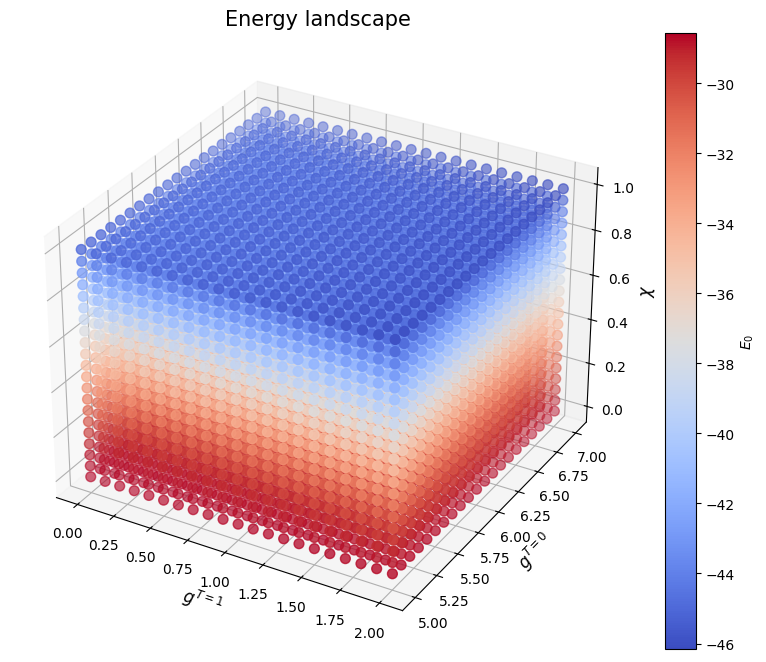

In [7]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(g_test[:, 0], g_test[:, 1], g_test[:, 2], 
                c=E_test[:,0], cmap='coolwarm', s=50)

plt.colorbar(sc, label='$E_0$')
ax.set_xlabel('$g^{T=1}$', fontsize=12)
ax.set_ylabel('$g^{T=0}$', fontsize=12)
ax.set_zlabel('$\chi$', fontsize=12)
ax.set_title('Energy landscape', fontsize=15)
plt.show()

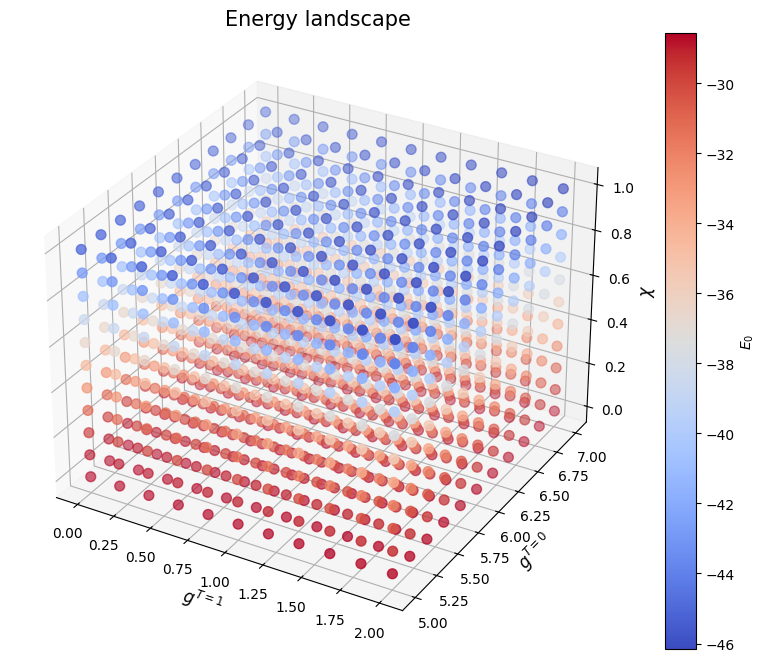

In [8]:
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

sc = ax.scatter(g_train[:, 0], g_train[:, 1], g_train[:, 2], 
                c=E_train[:, 0], cmap='coolwarm', s=50)

plt.colorbar(sc, label='$E_0$')
ax.set_xlabel('$g^{T=1}$', fontsize=12)
ax.set_ylabel('$g^{T=0}$', fontsize=12)
ax.set_zlabel('$\chi$', fontsize=12)
ax.set_title('Energy landscape', fontsize=15)
plt.show()

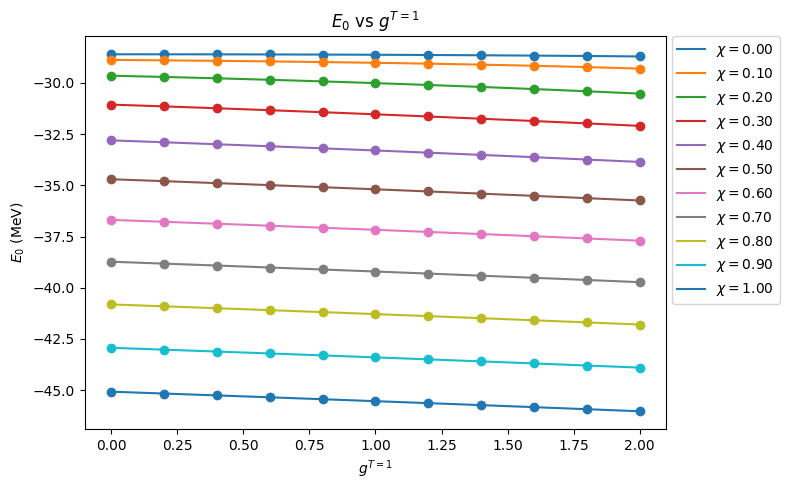

In [10]:
g0_vals = np.unique(g_train[:, 1])
g0_fixed = g0_vals[len(g0_vals) // 2]

chi_vals_train = np.unique(g_train[:, 2])
chi_vals_test  = np.unique(g_test[:, 2])
g1_vals_test   = np.unique(g_test[:, 0])

fig, ax = plt.subplots(figsize=(8, 5))

for chi in chi_vals_train:
    chi_near = chi_vals_test[np.argmin(np.abs(chi_vals_test - chi))]

    # test line
    g0_test_fixed = np.unique(g_test[:, 1])[len(np.unique(g_test[:, 1])) // 2]
    mask = np.isclose(g_test[:, 2], chi_near,      atol=1e-10) & \
           np.isclose(g_test[:, 1], g0_test_fixed, atol=1e-10)
    g1, E = g_test[mask, 0], E_test[mask, 0]
    s = np.argsort(g1)
    ax.plot(g1[s], E[s], label=rf"$\chi={chi:.2f}$")

    # train dots
    mask = np.isclose(g_train[:, 2], chi,      atol=1e-10) & \
           np.isclose(g_train[:, 1], g0_fixed, atol=1e-10)
    ax.scatter(g_train[mask, 0], E_train[mask, 0], color=ax.lines[-1].get_color(), zorder=5)

ax.set_xlabel(r"$g^{T=1}$")
ax.set_ylabel(r"$E_0$ (MeV)")
ax.set_title(rf"$E_0$ vs $g^{{T=1}}$")
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.tight_layout()
plt.show()

Now, we construct our affine effective Hamiltonian PMM:

$$M(c)=A+cB$$

where $c$ is the input parameter/strength constant. 

In this example, we are considering all three input parameters of the collective Hamiltonian, so our affine effective PMM will look like:

$$M(c_1,c_2,c_3)=A+c_1  B+c_2 C+c_3  D$$

This multivariable dependence can be interpreted as the result of an scalar product:

$$A+c_1  B+c_2 C+c_3  D=M_0+\vec{c} \cdot \vec{M_1}$$

So we maintain our original PMM shape:

$$M(\vec{c})=M_0+\vec{c} \cdot \vec{M_1}$$

The PMM is trained with Adam gradient descent method for complex parameters.

In [ ]:
def M(A: jnp.ndarray, B: jnp.ndarray, c: jnp.ndarray) -> jnp.ndarray:
    """
    PMM Hamiltonian M(c) = A + c*B

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [3D jax array (l, n, n)]: Hermitian matrix
    c [2D jax array (N, l)]: array of c values

    Returns
    -------
    M [2D (n, n) or 3D jax array (N, n, n)]: PMM Hamiltonian M(c) = A + c*B
        if c is an array, M is a 3D array M[i] = A + sum_l c[i,l]*B[l]

    """
    # force Hermiticity
    A = (A + A.conj().T) / 2
    B = (B + jnp.conjugate(jnp.transpose(B, (0, 2, 1)))) / 2


    return A + jnp.einsum("il,ljk->ijk", c, B)


def get_eigen(
    A: jnp.ndarray, B: jnp.ndarray, cs: jnp.ndarray, k: int
) -> jnp.ndarray:
    """
    Get the k lowest eigenvalues of the PMM Hamiltonian M(c) = A + c*B

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [3D jax array (l, n, n)]: Hermitian matrix
    cs [2D jax array (N, l)]: array of c values
    k [int <= n]: number of lowest eigenvalues to return

    Returns
    -------
    E [2D jax array (N, k)]: array of the k lowest eigenvalues of M(c) = A + c*B for
        each c in cs.
        E[i,j] is the j-th lowest eigenvalue of M(cs[i])
    """

    E = jnp.linalg.eigvalsh(M(A, B, cs))[:, :k]

    return E


def loss(
    A: jnp.ndarray, B: jnp.ndarray, cs: jnp.ndarray, Es: jnp.ndarray
) -> jnp.ndarray:
    """
    Mean Squared Error loss function between the eigenvalues of the PMM
    Hamiltonian M(c) = A + c*B and the target eigenvalues Es

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [2D jax array (n, n)]: Hermitian matrix
    cs [1D jax array (N,)]: array of c values
    Es [2D jax array (N, k)]: target eigenvalues at each c value
    """

    k = Es.shape[1]
    pmm_E = get_eigen(A, B, cs, k)
    return jnp.mean(jnp.abs(pmm_E - Es) ** 2)


def complex_adam_update(
    param: jnp.ndarray,
    grad: jnp.ndarray,
    lr: float,
    m: jnp.ndarray,
    v: jnp.ndarray,
    i: int,
    beta1: float = 0.9,
    beta2: float = 0.999,
    eps: float = 1e-8,
    absmaxgrad: float = 1e3,
) -> (jnp.ndarray, jnp.ndarray, jnp.ndarray):
    """
    Adam optimizer update rule, modified for complex valued parameters

    Parameters
    ----------
    param [jax array]: parameter to update
    grad [jax array]: gradient of the loss function wrt param
    lr [float]: learning rate
    m [jax array]: Adam optimizer first moment estimate
    v [jax array]: Adam optimizer second moment estimate
    i [int]: iteration number
    beta1 [float]: Adam optimizer first moment decay rate
    beta2 [float]: Adam optimizer second moment decay rate
    eps [float]: Adam optimizer epsilon parameter
    absmaxgrad [float]: maximum absolute value of the gradient for clipping

    Returns
    -------
    param [jax array]: updated parameter
    m [jax array]: updated first moment estimate
    v [jax array]: updated second moment
    """

    # for complex valued parameters, conjugate the gradient
    # as the gradient descent update rule is
    # x = x - lr * dL/dconj(x)
    # which for real-valued loss functions is equivalent to
    # x = x - lr * conj(dL/dx)

    # we also clip the gradient to avoid exploding gradients
    conj_grad = jnp.clip(grad.real, -absmaxgrad, absmaxgrad) - 1j * jnp.clip(
        grad.imag, -absmaxgrad, absmaxgrad
    )

    # moment estimates
    m = beta1 * m + (1 - beta1) * conj_grad
    v = beta2 * v + (1 - beta2) * jnp.abs(conj_grad) ** 2
    # bias correction
    mhat = m / (1 - beta1 ** (i + 1))
    vhat = v / (1 - beta2 ** (i + 1))

    # update rule
    param = param - lr * mhat / (jnp.sqrt(vhat) + eps)

    return param, m, v


def train(
    A: jnp.ndarray,
    B: jnp.ndarray,
    cs_train: jnp.ndarray,
    Es_train: jnp.ndarray,
    lr: float = 1e-3,
    n_iter: int = 1000, 
    filename_loss=None,
    ):
    """
    Train the PMM Hamiltonian M(c) = A + c*B to match target eigenvalues
    Es_train at c values cs_train

    Parameters
    ----------
    A [2D jax array (n, n)]: Initial guess for Hermitian matrix A
    B [2D jax array (n, n)]: Initial guess for Hermitian matrix B
    cs_train [1D jax array (N,)]: array of c values to train on
    Es_train [2D jax array (N, k)]: target eigenvalues at each c value
    lr [float]: learning rate
    n_iter [int]: number of training iterations
    filename_loss [str or None]: if not None, filename to write loss values during training

    Returns
    -------
    A [2D jax array (n, n)]: trained Hermitian matrix A
    B [2D jax array (n, n)]: trained Hermitian matrix B
    """

    # initialize Adam optimizer
    m_A = jnp.zeros_like(A)
    v_A = jnp.zeros_like(A)
    m_B = jnp.zeros_like(B)
    v_B = jnp.zeros_like(B)

    # jit version of the loss function
    j_loss = jit(loss)

    # gradient of the loss function wrt A and B
    grad_loss = grad(j_loss, argnums=(0, 1))

    #if filename_loss is not None, open a file to write the loss values during training
    if filename_loss:
        with open(filename_loss, "w") as f_loss:
            f_loss.write("iteration\tloss\n")


    # training loop
    for i in range(n_iter):

        # compute the gradient of the loss function
        grad_A, grad_B = grad_loss(A, B, cs_train, Es_train)

        # update A and B
        A, m_A, v_A = complex_adam_update(A, grad_A, lr, m_A, v_A, i)
        B, m_B, v_B = complex_adam_update(B, grad_B, lr, m_B, v_B, i)


        # print loss every 100 iterations
        if i % 100 == 0:
            loss_val = j_loss(A, B, cs_train, Es_train)
            print(f"\r {i: <7} {loss_val: .4E}")
            if filename_loss:
                with open(filename_loss, "a") as f_loss:
                    f_loss.write(f"{i: <7}\t{loss_val: .4E}\n")

    A = (A + A.conj().T) / 2
    B = (B + jnp.conjugate(jnp.transpose(B, (0, 2, 1)))) / 2

    return A, B

def predict(A: jnp.ndarray, B: jnp.ndarray, cs: jnp.ndarray, k: int) -> jnp.ndarray:
    """
    Use the trained PMM Hamiltonian M(c) = A + c*B to predict the k lowest
    eigenvalues

    Parameters
    ----------
    A [2D jax array (n, n)]: Hermitian matrix
    B [2D jax array (n, n)]: Hermitian matrix
    cs [1D jax array (N,)]: array of c values
    k [int <= n]: number of lowest eigenvalues to return

    Returns
    -------
    E [2D jax array (N, k)]: array of the k lowest eigenvalues of M(c) = A + c*B for
        each c in cs.
        E[i,j] is the j-th lowest eigenvalue of M(cs[i])
    """

    return get_eigen(A, B, cs, k)

With the PMM defined, we can begin training the model by minimizing the mean squared error between the true energy states and the predicted energy states.

In [ ]:
k=3 #number of eigenvalues to predict
X_train = jnp.array(g_train)
y_train = jnp.array(E_train)

n_valors=[12]

for n in n_valors:
    # initialize the PMM parameters
    #n=10 size of nxn PMM
    eg='012' #state to predict
    seed=42
    npar = 3 # number of input parameters (gT1, gT0, chi)
    min_eigen= k # number of lowest eigenvalues to predict
    lr = 0.01 # learning rate
    iterations = 20000 # number of training iterations

    # filename to write loss values during training
    filename=f"SMC_LOSS2_N{n}_EV{eg}_NS{min_eigen}_SEED{seed}_LR{lr}_IT{iterations}_T{ntrain}.txt"

    #filename to save the trained A and B matrices
    matrixname=f"SMC_MATRIX2_N{n}_EV{eg}_NS{min_eigen}_SEED{seed}_LR{lr}_IT{iterations}_T{ntrain}.npz"

    # training data consists only of the k lowest eigenvalues
    y_train_k = y_train[:, :min_eigen]

    np.random.seed(seed)

    # multiply all initial 'weights' by a small prefactor to help with training
    mag = 1e-1

    # Initialize A matrix
    A = np.random.randn(n, n) + 1j * np.random.randn(n, n)  # initialize the parameters
    A = (A + A.conj().T)/2
    A = mag * jnp.array(A)

    # Initialize B matrix
    B = np.random.randn(npar, n, n) + 1j * np.random.randn(npar,n, n)  # initialize the parameters
    B = (B + jnp.conjugate(jnp.transpose(B, (0, 2, 1)))) / 2
    B = mag * jnp.array(B)

    # train the model
    A, B = train(A, B, X_train, y_train_k, lr=lr, n_iter=iterations, filename_loss=filename)

    #save the trained A and B matrices to a .npz file
    np.savez(matrixname, A=np.array(A), B=np.array(B))

In [ ]:
#load previously trained A and B matrices
data=np.load("SMC_MATRIX2_N20_EV012_NS3_SEED42_LR0.01_IT10000_T11.npz")

k=3
A = jnp.array(data['A'])
B = jnp.array(data['B'])

data1 = np.load("SM_test_dataset_21.npz")

g_test = data1['arr_0']
E_test = data1['arr_1']

Finally, we use the trained PMM parameters to make a prediction on unseen data:

In [11]:
# make prediction
X_test = jnp.array(g_test)
y_test = jnp.array(E_test)
y_pred = predict(A, B, X_test, k)

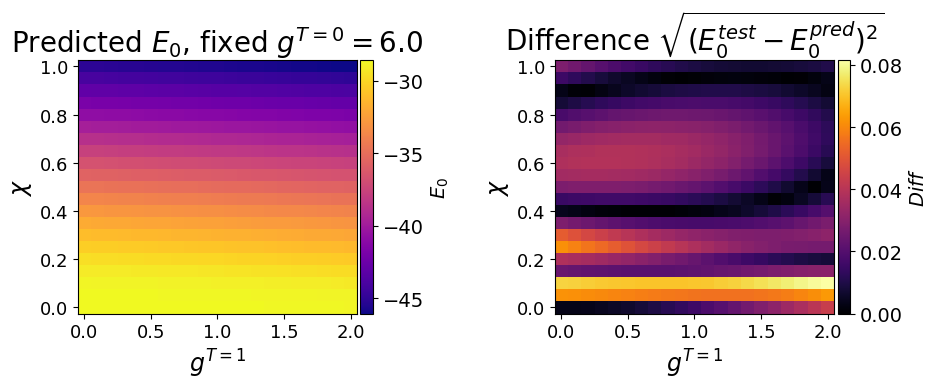

In [ ]:
from matplotlib.colors import Normalize
g0_fixed = 6.0

# Slice at fixed g0
mask = np.isclose(X_test[:, 1], g0_fixed, atol=1e-10)
g1   = X_test[mask, 0]
chi  = X_test[mask, 2]

E_pr = y_pred[mask, 0]
E_t = E_test[mask, 0]

# difference
diff = np.array(np.sqrt((E_pr - E_t)**2))



n = len(np.unique(g1))

g1_2d  = g1.reshape(n, n)
chi_2d = chi.reshape(n, n)
E_2d   = E_pr.reshape(n, n)
diff   = diff.reshape(n, n)



fig, axes = plt.subplots(1, 2, figsize=(9.5, 4))

norm1 = Normalize(vmin=E_2d.min(), vmax=E_2d.max()) 
norm2 = Normalize(vmin=0, vmax=diff.max())

im1 = axes[0].pcolormesh(g1_2d, chi_2d, E_2d, cmap="plasma", norm=norm1, shading="auto")
im2 = axes[1].pcolormesh(g1_2d, chi_2d, diff, cmap="inferno", norm=norm2, shading="auto")


cbar1 = fig.colorbar(im1, ax=axes[0], pad=0.01)
cbar1.set_label(r"$E_0$", fontsize=14)
cbar1.ax.tick_params(labelsize=14)     

cbar2 = fig.colorbar(im2, ax=axes[1], pad=0.01)
cbar2.set_label(r"$Diff$", fontsize=14)
cbar2.ax.tick_params(labelsize=14)



axes[0].set_title(rf"Predicted $E_0$, fixed $g^{{T=0}}={g0_fixed}$", fontsize=20)
axes[1].set_title(r"Difference $\sqrt{(E_0^{test} - E_0^{pred})^2}$", fontsize=20)

axes[0].set_xlabel(r"$g^{T=1}$", fontsize=17)
axes[1].set_xlabel(r"$g^{T=1}$", fontsize=17)

axes[0].set_ylabel(r"$\chi$", fontsize=17)
axes[1].set_ylabel(r"$\chi$", fontsize=17)

axes[0].tick_params(axis='both', which='major', labelsize=13)
axes[1].tick_params(axis='both', which='major', labelsize=13)

plt.tight_layout()
plt.savefig("pmm_predicted_heatmap_n20.pdf", dpi=300)
plt.show()

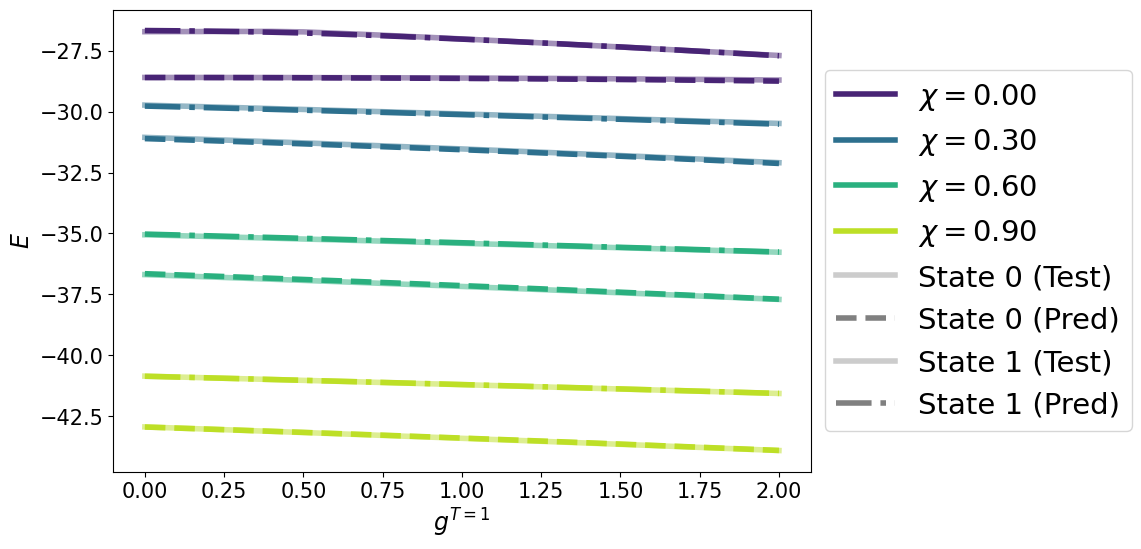

In [17]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D

# indexed [g1, g0, chi] to change the studied parameter more easily
fixed = 1
lines = 2
vsval = 0
states = 2

g0_vals = np.unique(X_test[:, fixed])
g0_fixed = g0_vals[len(g0_vals) // 2]

chi_vals_test = np.unique(g_test[:, lines])
chi_vals_plot = chi_vals_test[::6]
num_chis = len(chi_vals_plot)

fig, ax = plt.subplots(figsize=(9, 6))

ax.tick_params(axis='both', which='major', labelsize=14)

cmap = plt.get_cmap("viridis")
colors = [cmap(i) for i in np.linspace(0.1, 0.9, num_chis)]

#test_linestyles = ["-", ":"]
pred_linestyles = ["--", "-.",":"]
lw = 4


for idx in range(num_chis):
    chi = chi_vals_plot[idx]
    current_color = colors[idx]  

    g0_test_fixed = np.unique(g_test[:, fixed])[
        len(np.unique(g_test[:, fixed])) // 2
    ]
    mask = np.isclose(g_test[:, lines], chi, atol=1e-10) & np.isclose(
        g_test[:, fixed], g0_test_fixed, atol=1e-10
    )
    g1, E = g_test[mask, vsval], E_test[mask, :states]
    s = np.argsort(g1)

    for state_idx in range(states):
        ax.plot(g1[s], E[s, state_idx], linestyle='-', color=current_color, linewidth=lw, alpha=0.5)

    mask = np.isclose(X_test[:, lines], chi, atol=1e-10) & np.isclose(
        X_test[:, fixed], g0_fixed, atol=1e-10
    )
    g1_pred = X_test[mask, vsval]
    E_pred = y_pred[mask, :states]
    s2 = np.argsort(g1_pred)

    for state_idx in range(states):
        ax.plot(g1_pred[s2], E_pred[s2, state_idx], linestyle=pred_linestyles[state_idx], color=current_color,
                 linewidth=lw, alpha=1.0)

#the initial idea was to make two separate legends, one for the chi values and one for the states
chi_legend = []
for idx, chi in enumerate(chi_vals_plot):
    chi_legend.append(Line2D([0], [0], color=colors[idx], lw=4, label=rf"$\chi = {chi:.2f}$"))

states_legend = [
    Line2D([0], [0], color="gray", linestyle="-", alpha=0.4, lw=lw, label="State 0 (Test)"),
    Line2D([0], [0], color="gray", linestyle="--", alpha=1.0, lw=lw, label="State 0 (Pred)"),
    Line2D([0], [0], color="gray", linestyle="-", alpha=0.4, lw=lw, label="State 1 (Test)"),
    Line2D([0], [0], color="gray", linestyle="-.", alpha=1.0, lw=lw, label="State 1 (Pred)"),
]

ax.set_xlabel(r"$g^{T=1}$", fontsize=17)
ax.set_ylabel(r"$E$", fontsize=17)
#ax.set_title(rf"$E$ vs $g^{{T=1}}$", fontsize=15)

ax.legend(
    handles=chi_legend+states_legend,
    bbox_to_anchor=(1.02, 0.87),
    loc="upper left",
    borderaxespad=0,
    fontsize=21,
)

plt.tick_params(axis='both', which='major', labelsize=15)
plt.savefig("predicted_excited_states2_n20.pdf", dpi=300, bbox_inches='tight')
plt.show()

Additionally, we can read out the matrix elements of the PMM.

In [ ]:
A_disp = np.array2string(A, precision=4, floatmode='fixed')
B_disp = np.array2string(B, precision=4, floatmode='fixed')

print("=== A ===")
print(A_disp)
print("=== B ===")
print(B_disp)

In [ ]:
A_np = np.array(A)  # converts JAX to numpy
A_sym = sp.Matrix([[sp.Float(complex(x).real, 4) + sp.Float(complex(x).imag, 4)*sp.I 
                    for x in row] for row in A_np])
display(A_sym)

Matrix([
[           -5.645,  -6.416 + 5.391*I,   4.387 - 5.689*I,  4.865 + 6.374*I, -4.614 - 6.164*I,  -5.666 + 4.047*I,   0.934 + 6.431*I,  7.854 + 2.968*I, -7.006 + 0.6335*I,  5.335 - 3.879*I],
[ -6.416 - 5.391*I,            -6.918,  -6.489 + 4.709*I, -5.782 + 5.471*I, -6.123 - 4.226*I,  -5.974 + 2.582*I, -8.105 - 0.7793*I, 7.124 - 0.3255*I,   -3.729 + 7.23*I,  -10.5 + 2.286*I],
[  4.387 + 5.689*I,  -6.489 - 4.709*I,             -5.94,  -6.689 - 4.26*I,  5.751 + 5.453*I, -0.8196 + 8.345*I,   -3.41 - 3.465*I,  3.363 - 5.629*I,  0.6133 + 7.105*I, -3.175 - 7.788*I],
[  4.865 - 6.374*I,  -5.782 - 5.471*I,   -6.689 + 4.26*I,           -6.391,   6.11 - 2.689*I,    -7.2 + 6.059*I,  -6.299 + 1.387*I, -4.828 - 6.359*I,  -5.106 - 4.302*I, -2.271 + 4.282*I],
[ -4.614 + 6.164*I,  -6.123 + 4.226*I,   5.751 - 5.453*I,   6.11 + 2.689*I,           -6.727,  -7.478 - 3.323*I,   4.656 - 5.974*I, -2.213 - 6.807*I,  -6.044 + 2.693*I, -7.263 + 6.862*I],
[ -5.666 - 4.047*I,  -5.974 - 2.582*I, -0.8196 - 8.

In [ ]:
B_np = np.array(B)  # converts JAX to numpy
B_sym = sp.Matrix([[sp.Float(complex(x).real, 4) + sp.Float(complex(x).imag, 4)*sp.I 
                    for x in row] for row in B_np])
display(B_sym)

Matrix([
[               1.08,  -0.8987 + 0.1882*I,   0.9895 + 0.2207*I,  -0.2398 + 0.5946*I, -0.4673 + 0.7628*I, -0.3176 + 0.06802*I,   0.2942 + 0.3014*I,   1.196 - 0.1967*I,  -0.4601 + 0.2802*I,   0.8463 - 0.4464*I],
[ -0.8987 - 0.1882*I,              0.8403,  -0.3478 + 0.1069*I, -0.04745 - 0.1213*I, 0.06689 + 0.2019*I,  -0.2263 - 0.1003*I,   -0.148 + 0.0147*I, -0.3979 + 0.1364*I,   0.2981 + 0.2629*I,   -1.084 + 0.2899*I],
[  0.9895 - 0.2207*I,  -0.3478 - 0.1069*I,             0.09161, -0.01447 + 0.5209*I, -0.4699 - 0.5109*I,  0.3867 + 0.05222*I,  -0.2837 - 0.4064*I,  0.2552 - 0.7452*I,   0.3126 + 0.3444*I,  0.9841 - 0.08284*I],
[ -0.2398 - 0.5946*I, -0.04745 + 0.1213*I, -0.01447 - 0.5209*I,             -0.4043, 0.6024 + 0.05457*I,   0.5839 + 0.2595*I,  0.03521 - 0.4514*I,   0.529 - 0.8199*I, -0.0691 - 0.03265*I,  0.08698 + 0.3249*I],
[ -0.4673 - 0.7628*I,  0.06689 - 0.2019*I,  -0.4699 + 0.5109*I,  0.6024 - 0.05457*I,            -0.8675,    -0.385 + 0.214*I,   -0.4119 - 0.736*I, -0.4